In [2]:
pip install opencv-python tensorflow scikit-learn seaborn

In [1]:
import os
import warnings
import numpy as np
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, GlobalAveragePooling2D,
    Dense, Dropout, BatchNormalization, Input
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import zipfile
import shutil

warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')
print("✅ Libraries imported")

✅ Libraries imported


In [2]:
drive.mount('/content/drive')

# Extract zip file
zip_path = '/content/drive/MyDrive/ECG_DATA.zip'
extract_path = '/content/ECG_DATA'

if not os.path.exists(extract_path):
    print("📦 Extracting ECG_DATA.zip...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"✅ Extracted to {extract_path}")
else:
    print(f"✅ Already extracted at {extract_path}")

# List structure
print("\n📁 Directory structure:")
for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 2 * (level + 1)
    for file in files[:3]:
        print(f"{subindent}{file}")
    if len(files) > 3:
        print(f"{subindent}... and {len(files) - 3} more files")

Mounted at /content/drive
📦 Extracting ECG_DATA.zip...
✅ Extracted to /content/ECG_DATA

📁 Directory structure:
ECG_DATA/
  train/
    Normal Person ECG Images (284x12=3408)/
      Normal(98) - Copy.jpg
      Normal(44) - Copy.jpg
      Normal(259).jpg
      ... and 849 more files
    ECG Images of Patient that have History of MI (172x12=2064)/
      PMI(87).jpg
      PMI(246) - Copy.jpg
      PMI(130).jpg
      ... and 513 more files
    ECG Images of Patient that have abnormal heartbeat (233x12=2796)/
      HB(442) - Copy.jpg
      HB(162) - Copy.jpg
      HB(337) - Copy.jpg
      ... and 696 more files
    ECG Images of Myocardial Infarction Patients (240x12=2880)/
      MI(4) - Copy - Copy.jpg
      MI(155).jpg
      MI(145) - Copy.jpg
      ... and 953 more files
  test/
    Normal Person ECG Images (284x12=3408)/
      Normal(259).jpg
      Normal(12).jpg
      Normal(262).jpg
      ... and 281 more files
    ECG Images of Patient that have History of MI (172x12=2064)/
      PMI(

In [3]:
# ── config ──────────────────────────────────────────
TRAIN_PATH   = '/content/ECG_DATA/train'
TEST_PATH    = '/content/ECG_DATA/test'
IMG_SIZE     = 64
BATCH_SIZE   = 32
EPOCHS       = 16
LR           = 1e-3
# ────────────────────────────────────────────────────

# Get classes from train folder
classes = sorted([
    f for f in os.listdir(TRAIN_PATH)
    if os.path.isdir(os.path.join(TRAIN_PATH, f))
])
NUM_CLASSES = len(classes)
print(f"📁 Classes ({NUM_CLASSES}): {classes}")

📁 Classes (4): ['ECG Images of Myocardial Infarction Patients (240x12=2880)', 'ECG Images of Patient that have History of MI (172x12=2064)', 'ECG Images of Patient that have abnormal heartbeat (233x12=2796)', 'Normal Person ECG Images (284x12=3408)']


In [4]:
def load_dataset(dataset_path, classes, img_size=128, augment=True):
    """Load + augment ECG images from dataset folder structure. Returns float32 arrays."""

    def _augment(img):
        h, w = img.shape[:2]
        cx, cy = w / 2, h / 2
        yield cv2.flip(img, 1)
        yield cv2.flip(img, 0)
        for angle in (15, -15):
            M = cv2.getRotationMatrix2D((cx, cy), angle, 1)
            yield cv2.warpAffine(img, M, (w, h))
        yield cv2.convertScaleAbs(img, alpha=1.3, beta=0)
        yield cv2.GaussianBlur(img, (3, 3), 0)

    X, y = [], []
    for label, cls in enumerate(classes):
        cls_path = os.path.join(dataset_path, cls)
        if not os.path.exists(cls_path):
            print(f"  ⚠️  Path not found: {cls_path}")
            continue

        files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        print(f"  Loading {cls}: {len(files)} images", end='')
        n_aug = 0

        for fname in files:
            img_path = os.path.join(cls_path, fname)
            img = cv2.imread(img_path)
            if img is None:
                continue

            img = cv2.resize(img, (img_size, img_size))
            X.append(img.astype(np.float32) / 255.0)
            y.append(label)

            if augment:
                for aug in _augment(img):
                    X.append(aug.astype(np.float32) / 255.0)
                    y.append(label)
                    n_aug += 1

        print(f" → +{n_aug} augmented")

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int32)
    return X, y

print("✅ Load dataset function defined")

✅ Load dataset function defined


In [5]:
print("🔄 Loading training data...")
X_train, y_train = load_dataset(TRAIN_PATH, classes, IMG_SIZE, augment=True)
print(f"✅ Train Dataset: {X_train.shape}  |  Labels: {y_train.shape}")

print("\n🔄 Loading test data...")
X_test, y_test = load_dataset(TEST_PATH, classes, IMG_SIZE, augment=False)
print(f"✅ Test Dataset: {X_test.shape}  |  Labels: {y_test.shape}")

print(f"\nClass distribution in train set:")
for cls, label in zip(classes, range(NUM_CLASSES)):
    count = np.sum(y_train == label)
    print(f"  {cls}: {count}")

🔄 Loading training data...
  Loading ECG Images of Myocardial Infarction Patients (240x12=2880): 956 images → +5736 augmented
  Loading ECG Images of Patient that have History of MI (172x12=2064): 516 images → +3096 augmented
  Loading ECG Images of Patient that have abnormal heartbeat (233x12=2796): 699 images → +4194 augmented
  Loading Normal Person ECG Images (284x12=3408): 852 images → +5112 augmented
✅ Train Dataset: (21161, 64, 64, 3)  |  Labels: (21161,)

🔄 Loading test data...
  Loading ECG Images of Myocardial Infarction Patients (240x12=2880): 239 images → +0 augmented
  Loading ECG Images of Patient that have History of MI (172x12=2064): 172 images → +0 augmented
  Loading ECG Images of Patient that have abnormal heartbeat (233x12=2796): 233 images → +0 augmented
  Loading Normal Person ECG Images (284x12=3408): 284 images → +0 augmented
✅ Test Dataset: (928, 64, 64, 3)  |  Labels: (928,)

Class distribution in train set:
  ECG Images of Myocardial Infarction Patients (240x

In [6]:
def conv_block(filters, dropout=0.25):
    """Double conv + BN + pool + dropout."""
    return [
        Conv2D(filters, 3, padding='same', activation='relu',
               kernel_initializer='he_normal'),
        BatchNormalization(),
        Conv2D(filters, 3, padding='same', activation='relu',
               kernel_initializer='he_normal'),
        BatchNormalization(),
        MaxPooling2D(2),
        Dropout(dropout),
    ]


def build_cnn(input_shape=(128, 128, 3), lr=1e-3,
              filters=16, dropout=0.2, dense_units=128):
    model = Sequential([
        Input(shape=input_shape),
        *conv_block(filters,     dropout),
        *conv_block(filters * 2, dropout),
        *conv_block(filters * 4, dropout),
        GlobalAveragePooling2D(),
        Dense(dense_units, activation='relu',
              kernel_initializer='he_normal'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(NUM_CLASSES, activation='softmax'),
    ])
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model


def make_callbacks(patience_es=8, patience_lr=4):
    return [
        EarlyStopping(monitor='val_accuracy', patience=patience_es,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=patience_lr, min_lr=1e-7, verbose=1),
    ]

print("✅ Model builder functions ready")

✅ Model builder functions ready


In [7]:
print("🚀 Training baseline CNN…")
cnn_model = build_cnn(lr=LR, filters=32)
cnn_model.summary()

history_cnn = cnn_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    callbacks=make_callbacks(),
    verbose=1,
)

loss_cnn, acc_cnn = cnn_model.evaluate(X_test, y_test, verbose=0)
print(f"\n✅ CNN  —  Loss: {loss_cnn:.4f}  |  Accuracy: {acc_cnn*100:.2f}%")

🚀 Training baseline CNN…


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 306,340 (1.17 MB)

 Trainable params: 305,188 (1.16 MB)

 Non-trainable params: 1,152 (4.50 KB)

Epoch 1/16
529/529 ━━━━━━━━━━━━━━━━━━━━ 28s 22ms/step - accuracy: 0.5864 - loss: 1.0764 - val_accuracy: 0.0326 - val_loss: 3.1580 - learning_rate: 0.0010
Epoch 2/16
529/529 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.7716 - loss: 0.5880 - val_accuracy: 0.0000e+00 - val_loss: 5.2014 - learning_rate: 0.0010
Epoch 3/16
529/529 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.8534 - loss: 0.3821 - val_accuracy: 0.0928 - val_loss: 2.5744 - learning_rate: 0.0010
Epoch 4/16
529/529 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.9063 - loss: 0.2523 - val_accuracy: 0.1349 - val_loss: 2.8403 - learning_rate: 0.0010
Epoch 5/16
529/529 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9387 - loss: 0.1701 - val_accuracy: 0.2603 - val_loss: 2.1187 - learning_rate: 0.0010
Epoch 6/16
529/529 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9545 - loss: 0.1329 - val_accuracy: 0.8200 - val_loss: 0.4356 - learning_rate: 0.0010
Epoch 7/16
529/529 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.9660 - los

In [8]:
class HarrisHawksOptimizer:
    """Harris Hawks random-search hyperparameter optimizer."""

    def __init__(self, n_iter=10, search_space=None):
        self.n_iter = n_iter
        self.space  = search_space or {
            'lr':      (1e-4, 1e-3),
            'filters': (16, 64),
            'dropout': (0.2, 0.5),
        }
        self.best_acc    = 0.0
        self.best_params = None
        self.history     = []

    def _subset(self, n=300):
        idx = []
        for cls_label in np.unique(y_train):
            ci = np.where(y_train == cls_label)[0]
            idx.extend(ci[:max(1, n // NUM_CLASSES)])
        return np.array(idx)

    def _eval(self, lr, filters, dropout):
        model = build_cnn(lr=lr, filters=filters, dropout=dropout,
                          dense_units=128)
        idx = self._subset()
        cb  = EarlyStopping(monitor='val_accuracy', patience=3,
                            restore_best_weights=True, verbose=0)
        h = model.fit(
            X_train[idx], y_train[idx],
            epochs=10, batch_size=32,
            validation_split=0.2, callbacks=[cb], verbose=0,
        )
        tf.keras.backend.clear_session()
        return max(h.history['val_accuracy'])

    def _sample(self):
        lr      = np.random.uniform(*self.space['lr'])
        filters = int(np.random.randint(*self.space['filters']))
        dropout = np.random.uniform(*self.space['dropout'])
        return lr, filters, dropout

    def optimize(self):
        print(f"🦅 HHO: {self.n_iter} iterations\n")
        for i in range(1, self.n_iter + 1):
            lr, filters, dropout = self._sample()
            acc = self._eval(lr, filters, dropout)
            self.history.append(dict(lr=lr, filters=filters,
                                     dropout=dropout, val_acc=acc))
            tag = ''
            if acc > self.best_acc:
                self.best_acc    = acc
                self.best_params = dict(lr=lr, filters=filters,
                                        dropout=dropout)
                tag = '  ✅ best'
            print(f"  [{i:>2}/{self.n_iter}]  lr={lr:.5f}  "
                  f"filters={filters:>2}  dropout={dropout:.2f}  "
                  f"acc={acc*100:.2f}%  (best={self.best_acc*100:.2f}%){tag}")
        print(f"\n🏆 Best: {self.best_params}  →  {self.best_acc*100:.2f}%")
        return self.best_params

print("✅ HHO class defined")

✅ HHO class defined


In [9]:
hho      = HarrisHawksOptimizer(n_iter=10)
best_hho = hho.optimize()

print(f"\n🚀 Training CNN+HHO…")
hho_model = build_cnn(
    lr=best_hho['lr'],
    filters=best_hho['filters'],
    dropout=best_hho['dropout'],
)

history_hho = hho_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    callbacks=make_callbacks(),
    verbose=1,
)

loss_hho, acc_hho = hho_model.evaluate(X_test, y_test, verbose=0)
print(f"\n✅ CNN+HHO  —  Loss: {loss_hho:.4f}  |  Accuracy: {acc_hho*100:.2f}%")

🦅 HHO: 10 iterations

  [ 1/10]  lr=0.00058  filters=49  dropout=0.38  acc=100.00%  (best=100.00%)  ✅ best
  [ 2/10]  lr=0.00073  filters=21  dropout=0.30  acc=0.00%  (best=100.00%)
  [ 3/10]  lr=0.00038  filters=34  dropout=0.21  acc=100.00%  (best=100.00%)
  [ 4/10]  lr=0.00093  filters=24  dropout=0.27  acc=0.00%  (best=100.00%)
  [ 5/10]  lr=0.00019  filters=36  dropout=0.32  acc=86.67%  (best=100.00%)
  [ 6/10]  lr=0.00064  filters=55  dropout=0.49  acc=0.00%  (best=100.00%)
  [ 7/10]  lr=0.00080  filters=24  dropout=0.46  acc=0.00%  (best=100.00%)
  [ 8/10]  lr=0.00019  filters=23  dropout=0.35  acc=100.00%  (best=100.00%)
  [ 9/10]  lr=0.00026  filters=35  dropout=0.29  acc=100.00%  (best=100.00%)
  [10/10]  lr=0.00038  filters=18  dropout=0.27  acc=0.00%  (best=100.00%)

🏆 Best: {'lr': 0.0005806853578575953, 'filters': 49, 'dropout': 0.3813680838598301}  →  100.00%

🚀 Training CNN+HHO…
Epoch 1/16
529/529 ━━━━━━━━━━━━━━━━━━━━ 32s 36ms/step - accuracy: 0.5396 - loss: 1.1863 - val

In [10]:
class SuperEagleOptimizer:
    """Eagle-inspired random search optimizer."""

    def __init__(self, n_iter=10):
        self.n_iter = n_iter

    def _eval(self, lr, filters):
        model = build_cnn(lr=lr, filters=filters, dense_units=128)
        idx   = np.random.choice(len(X_train), min(300, len(X_train)), replace=False)
        cb    = EarlyStopping(monitor='val_accuracy', patience=3,
                              restore_best_weights=True, verbose=0)
        h = model.fit(
            X_train[idx], y_train[idx],
            epochs=10, batch_size=32,
            validation_split=0.2, callbacks=[cb], verbose=0,
        )
        tf.keras.backend.clear_session()
        return max(h.history['val_accuracy'])

    def optimize(self):
        best_acc, best = 0, None
        print(f"🦅 SuperEagle: {self.n_iter} iterations\n")
        for i in range(1, self.n_iter + 1):
            lr      = np.random.uniform(1e-4, 1e-3)
            filters = int(np.random.randint(16, 64))
            acc     = self._eval(lr, filters)
            tag = ''
            if acc > best_acc:
                best_acc = acc
                best     = dict(lr=lr, filters=filters)
                tag = '  ✅ best'
            print(f"  [{i:>2}/{self.n_iter}]  lr={lr:.5f}  "
                  f"filters={filters:>2}  acc={acc*100:.2f}%{tag}")
        print(f"\n🏆 Best: {best}  →  {best_acc*100:.2f}%")
        return best

print("✅ SuperEagle class defined")

✅ SuperEagle class defined


In [11]:
eagle_opt  = SuperEagleOptimizer(n_iter=10)
best_eagle = eagle_opt.optimize()

print("\n🚀 Training CNN+SuperEagle…")
eagle_model = build_cnn(lr=best_eagle['lr'], filters=best_eagle['filters'])

history_eagle = eagle_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    callbacks=make_callbacks(),
    verbose=1,
)

loss_eagle, acc_eagle = eagle_model.evaluate(X_test, y_test, verbose=0)
print(f"\n✅ CNN+SuperEagle  —  Loss: {loss_eagle:.4f}  |  Accuracy: {acc_eagle*100:.2f}%")

🦅 SuperEagle: 10 iterations

  [ 1/10]  lr=0.00084  filters=58  acc=16.67%  ✅ best
  [ 2/10]  lr=0.00047  filters=33  acc=36.67%  ✅ best
  [ 3/10]  lr=0.00018  filters=18  acc=21.67%
  [ 4/10]  lr=0.00041  filters=31  acc=26.67%
  [ 5/10]  lr=0.00062  filters=43  acc=31.67%
  [ 6/10]  lr=0.00059  filters=58  acc=30.00%
  [ 7/10]  lr=0.00056  filters=23  acc=36.67%
  [ 8/10]  lr=0.00030  filters=48  acc=31.67%
  [ 9/10]  lr=0.00032  filters=48  acc=36.67%
  [10/10]  lr=0.00032  filters=42  acc=26.67%

🏆 Best: {'lr': 0.00047205435158041183, 'filters': 33}  →  36.67%

🚀 Training CNN+SuperEagle…
Epoch 1/16
529/529 ━━━━━━━━━━━━━━━━━━━━ 27s 27ms/step - accuracy: 0.5467 - loss: 1.1805 - val_accuracy: 0.0158 - val_loss: 2.7939 - learning_rate: 4.7205e-04
Epoch 2/16
529/529 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.7107 - loss: 0.7561 - val_accuracy: 0.0092 - val_loss: 4.3298 - learning_rate: 4.7205e-04
Epoch 3/16
529/529 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.8041 - loss: 0.52

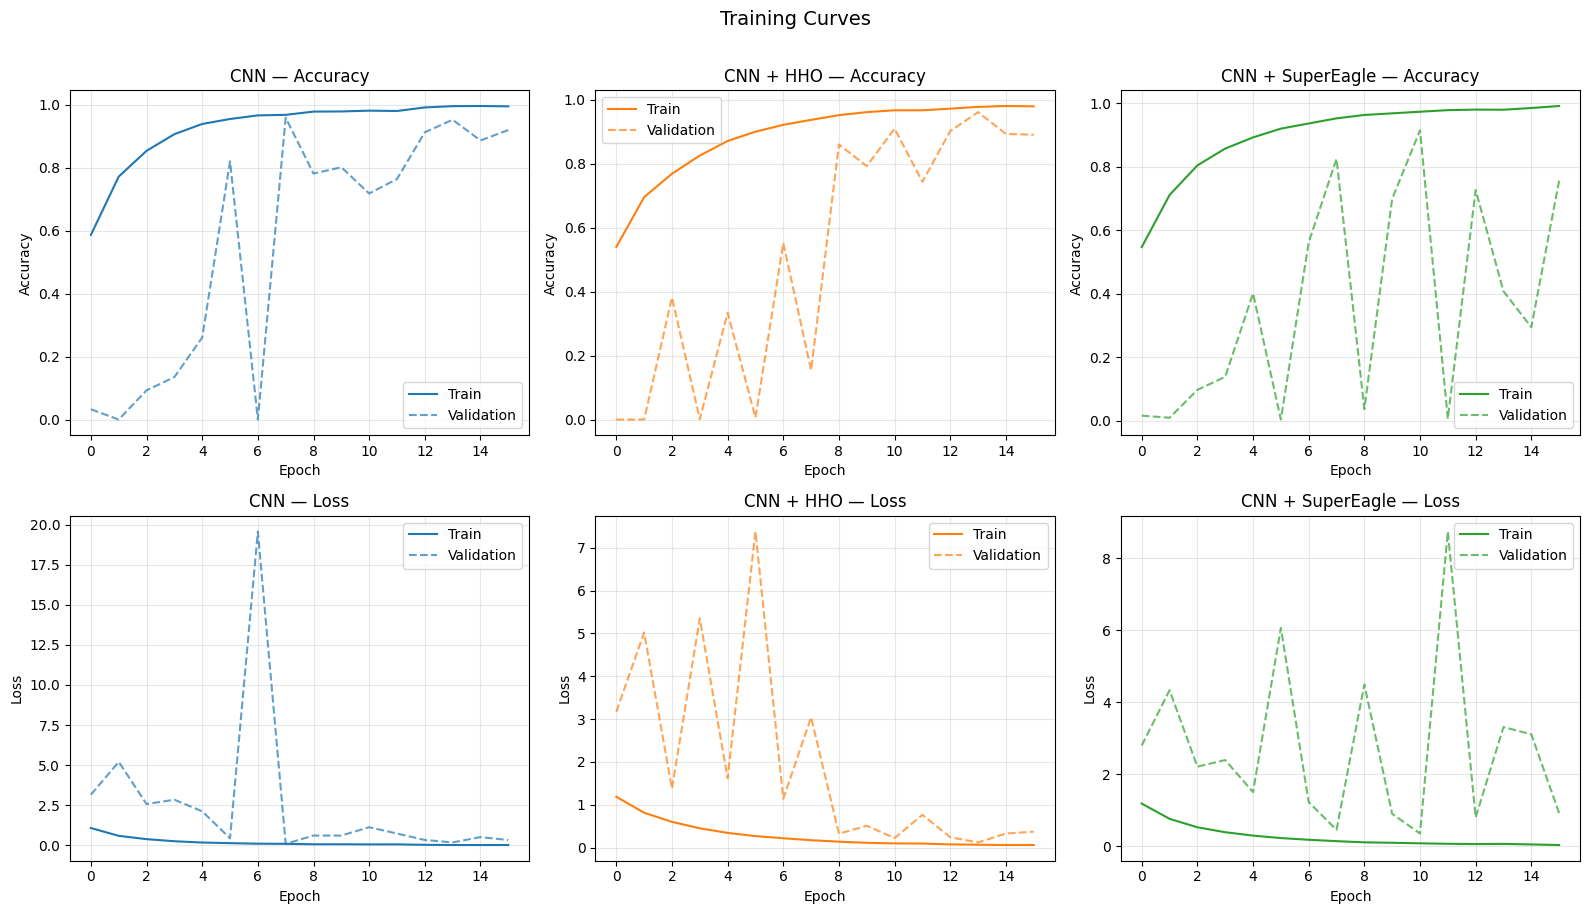

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
configs = [
    (history_cnn,   'CNN',              'tab:blue'),
    (history_hho,   'CNN + HHO',        'tab:orange'),
    (history_eagle, 'CNN + SuperEagle', 'tab:green'),
]

for col, (hist, name, color) in enumerate(configs):
    for row, (key, label) in enumerate([('accuracy','Accuracy'),('loss','Loss')]):
        ax = axes[row, col]
        ax.plot(hist.history[key],         label='Train',      color=color)
        ax.plot(hist.history[f'val_{key}'],label='Validation', color=color,
                linestyle='--', alpha=0.7)
        ax.set_title(f'{name} — {label}')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(label)
        ax.legend()
        ax.grid(alpha=0.3)

plt.suptitle('Training Curves', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

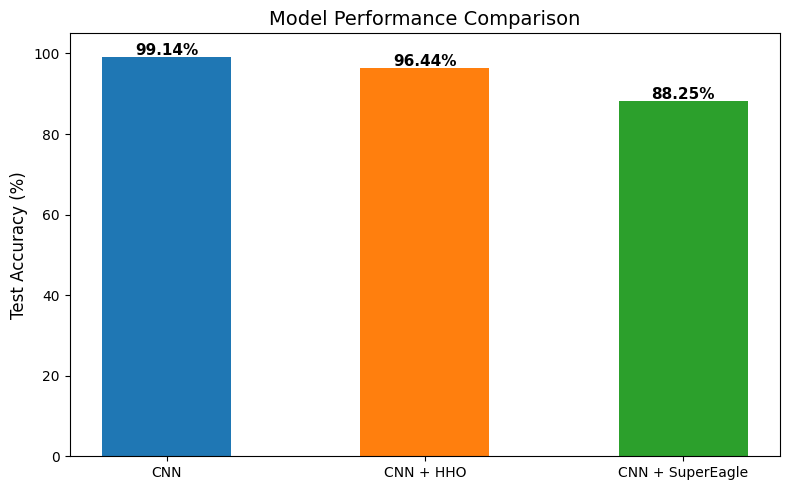

In [13]:
model_names = ['CNN', 'CNN + HHO', 'CNN + SuperEagle']
accuracies  = [acc_cnn * 100, acc_hho * 100, acc_eagle * 100]
colors      = ['#1f77b4', '#ff7f0e', '#2ca02c']

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, accuracies, color=colors, width=0.5)
plt.ylabel('Test Accuracy (%)', fontsize=12)
plt.title('Model Performance Comparison', fontsize=14)
plt.ylim([0, 105])
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.5,
             f'{acc:.2f}%', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/bar_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
def plot_cm(model, title):
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    cm = confusion_matrix(y_test, y_pred)

    fig, ax = plt.subplots(figsize=(10, 8))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=classes,
        yticklabels=classes,
        linewidths=1.5,
        linecolor='white',
        annot_kws={'size': 13},
        square=True,
        ax=ax,
    )

    ax.set_title(f'{title} — Confusion Matrix', fontsize=15, pad=18)
    ax.set_ylabel('Actual',    fontsize=12, labelpad=12)
    ax.set_xlabel('Predicted', fontsize=12, labelpad=12)
    ax.tick_params(axis='x', labelsize=11, rotation=30)
    ax.tick_params(axis='y', labelsize=11, rotation=0)

    plt.tight_layout(pad=2.5)
    plt.savefig(
        f'/content/cm_{title.replace(" ", "_")}.png',
        dpi=150, bbox_inches='tight'
    )
    plt.show()
    plt.close(fig)
    return y_pred

print("✅ Confusion matrix function defined")

✅ Confusion matrix function defined


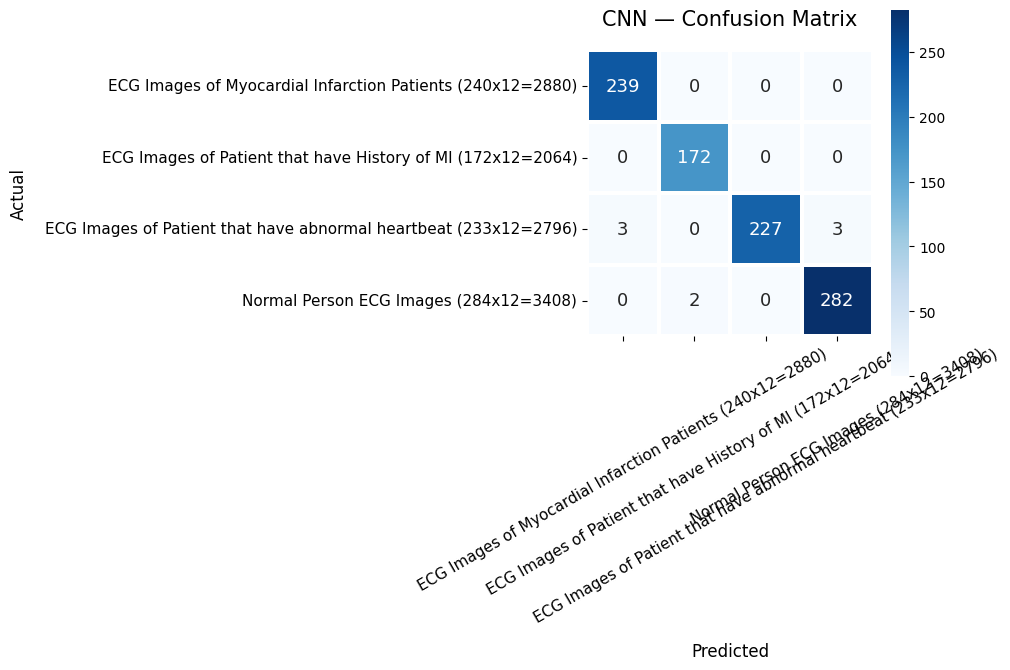

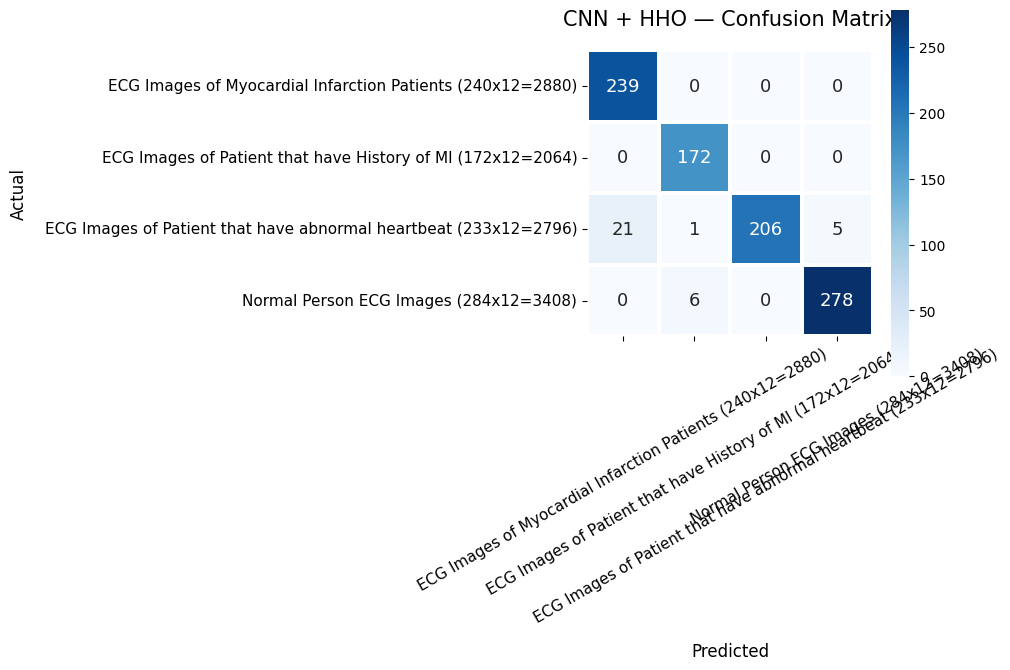

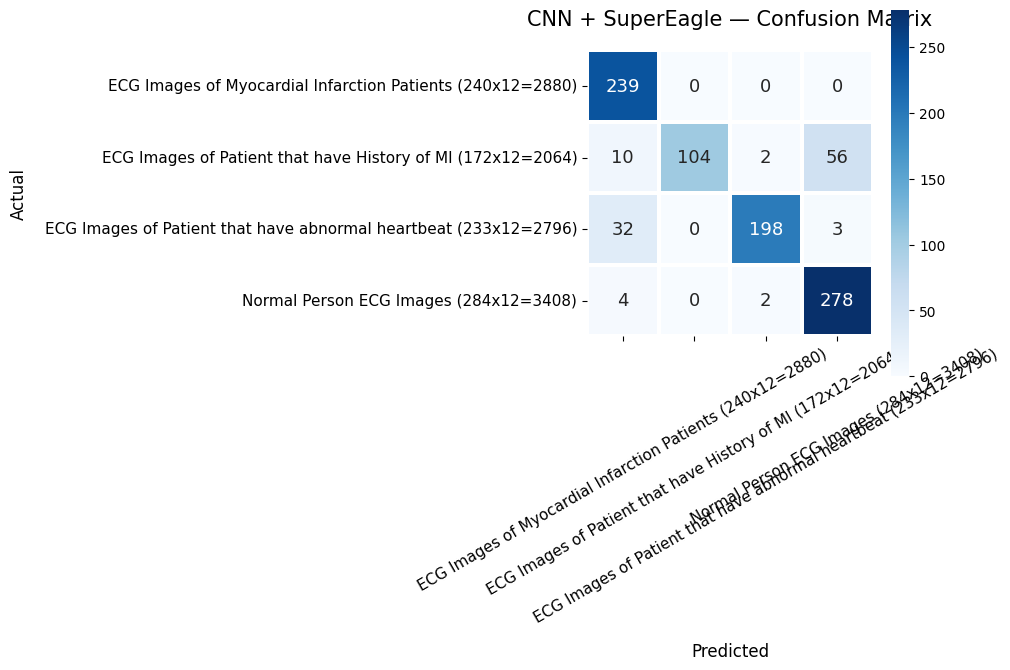

In [15]:
y_pred_cnn   = plot_cm(cnn_model,   'CNN')
y_pred_hho   = plot_cm(hho_model,   'CNN + HHO')
y_pred_eagle = plot_cm(eagle_model, 'CNN + SuperEagle')

In [16]:
sep = '=' * 55
for name, y_pred in [
    ('CNN',              y_pred_cnn),
    ('CNN + HHO',        y_pred_hho),
    ('CNN + SuperEagle', y_pred_eagle),
]:
    print(f"\n{sep}\n{name}\n{sep}")
    print(classification_report(y_test, y_pred, target_names=classes))


CNN
                                                                  precision    recall  f1-score   support

      ECG Images of Myocardial Infarction Patients (240x12=2880)       0.99      1.00      0.99       239
     ECG Images of Patient that have History of MI (172x12=2064)       0.99      1.00      0.99       172
ECG Images of Patient that have abnormal heartbeat (233x12=2796)       1.00      0.97      0.99       233
                          Normal Person ECG Images (284x12=3408)       0.99      0.99      0.99       284

                                                        accuracy                           0.99       928
                                                       macro avg       0.99      0.99      0.99       928
                                                    weighted avg       0.99      0.99      0.99       928


CNN + HHO
                                                                  precision    recall  f1-score   support

      ECG Images of Myocar

In [17]:
model_names = ['CNN', 'CNN + HHO', 'CNN + SuperEagle']
accuracies  = [acc_cnn * 100, acc_hho * 100, acc_eagle * 100]
best_idx    = int(np.argmax(accuracies))

print("=" * 45)
print("FINAL RESULTS")
print("=" * 45)
for name, acc in zip(model_names, accuracies):
    tag = '  ← best' if name == model_names[best_idx] else ''
    print(f"  {name:<22} {acc:.2f}%{tag}")
print("=" * 45)
print(f"\n🏆 Winner: {model_names[best_idx]}  →  {accuracies[best_idx]:.2f}%")

FINAL RESULTS
  CNN                    99.14%  ← best
  CNN + HHO              96.44%
  CNN + SuperEagle       88.25%

🏆 Winner: CNN  →  99.14%
